<a href="https://colab.research.google.com/github/shankar-011/GenAI-Internship/blob/master/Day4/DAY4(image_preprocessing).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from PIL import Image
image = Image.open("/content/images (1).jpg")

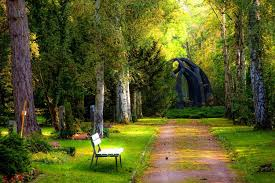

In [ ]:
image_resized = image.resize((800, 224*2))
image

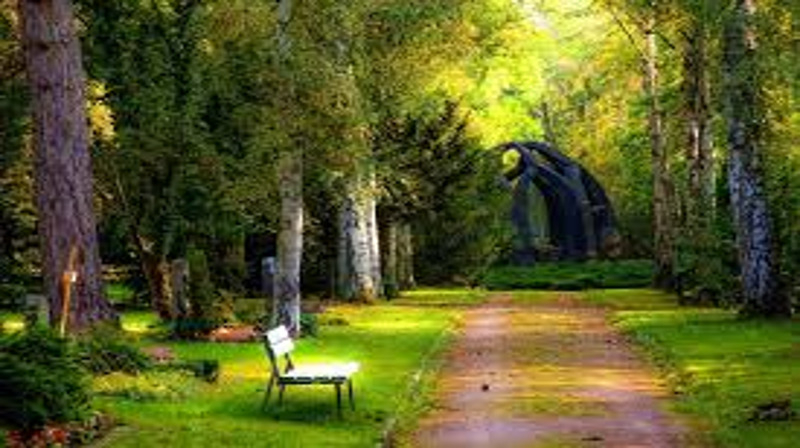

In [ ]:
image_resized

In [ ]:
import numpy as np
image_array = np.array(image)/255.0
image_array

array([[[0.25098039, 0.17254902, 0.        ],
        [0.44705882, 0.36078431, 0.16470588],
        [0.58039216, 0.4745098 , 0.29019608],
        ...,
        [0.29411765, 0.3372549 , 0.10980392],
        [0.30588235, 0.35294118, 0.10980392],
        [0.24313725, 0.29019608, 0.04705882]],

       [[0.43921569, 0.36078431, 0.16078431],
        [0.57647059, 0.49803922, 0.29803922],
        [0.49411765, 0.39215686, 0.2       ],
        ...,
        [0.3254902 , 0.36862745, 0.13333333],
        [0.31372549, 0.36078431, 0.10980392],
        [0.27058824, 0.31764706, 0.06666667]],

       [[0.47843137, 0.41176471, 0.2       ],
        [0.39607843, 0.32941176, 0.11764706],
        [0.23921569, 0.14901961, 0.        ],
        ...,
        [0.29019608, 0.3372549 , 0.07843137],
        [0.25098039, 0.30980392, 0.03921569],
        [0.25098039, 0.30980392, 0.03921569]],

       ...,

       [[0.07058824, 0.16470588, 0.        ],
        [0.10980392, 0.16078431, 0.        ],
        [0.25490196, 0

array([[ 33,  80, 110, ...,  67,  70,  54],
       [ 79, 114,  88, ...,  75,  71,  60],
       [ 91,  70,  29, ...,  65,  57,  57],
       ...,
       [ 27,  27,  42, ...,  57,  61,  66],
       [ 37,  47,  67, ...,  55,  59,  66],
       [ 45,  41,  23, ...,  62,  62,  61]], dtype=uint8)
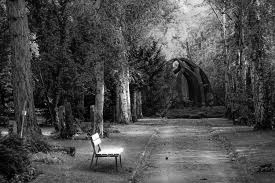

In [ ]:
from cv2 import cvtColor,COLOR_BGR2GRAY
image_np = np.array(image)
grayscale = cvtColor(image_np,COLOR_BGR2GRAY)
grayscale

DATA AUGMENTATION

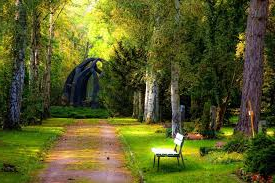

In [ ]:
from PIL import Image,ImageEnhance, ImageOps
import os
flipped = ImageOps.mirror(image)
flipped

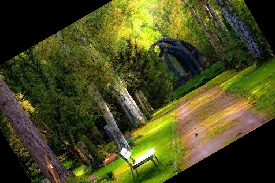

In [ ]:
rotated = image.rotate(30)
rotated

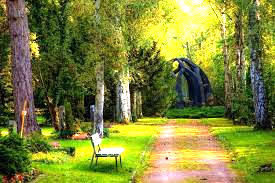

In [ ]:
enhancer = ImageEnhance.Brightness(image)
brighter = enhancer.enhance(1.5)
brighter

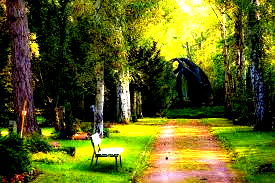

In [ ]:
contrast = ImageEnhance.Contrast(image).enhance(2.0)
contrast

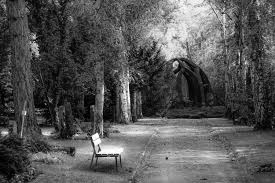

In [ ]:
grayscale = ImageOps.grayscale(image)
grayscale

In [ ]:
from PIL import Image, ImageEnhance, ImageOps
#PIL: Python Imaging Library (via Pillow), used for image processing.
#Image: Handles image loading, saving, and manipulation.
#ImageEnhance: Provides tools for enhancing image properties like brightness and contrast.
#ImageOps: Contains image processing utilities, such as flipping and grayscaling.
#os: A module to handle file system operations like creating directories and file paths.

import os

# Load the uploaded image
image_path = "/content/images (1).jpg"  # Replace with your image file path
image = Image.open(image_path)

# Create a directory for augmented images
augmented_dir = "augmented_images"
#Creates the directory augmented_images
os.makedirs(augmented_dir, exist_ok=True)
 #Ensures no error is raised if the directory already exists.

# Augmentation functions
def augment_image(image, output_dir):
    # 1. Horizontal Flip
    # Flips the image horizontally (mirroring).
    flipped = ImageOps.mirror(image)
    #Saves the flipped image as flipped.jpeg in the output_dir
    flipped.save(os.path.join(output_dir, "flipped.jpeg"))

    # 2. Rotate
    rotated = image.rotate(30)
    #Rotates the image by 30 degrees (counterclockwise by default)
    rotated.save(os.path.join(output_dir, "rotated.jpeg"))

    # 3. Brightness Adjustment
    enhancer = ImageEnhance.Brightness(image)
    #Adjusts brightness by a factor of 1.5 (1.0 = original brightness).
    brighter = enhancer.enhance(1.5)
    brighter.save(os.path.join(output_dir, "brighter.jpeg"))

    # 4. Contrast Adjustment
    contrast = ImageEnhance.Contrast(image).enhance(2.0)
    #Doubles the image's contrast (2.0 = twice the original contrast).

    contrast.save(os.path.join(output_dir, "contrast.jpeg"))

    # 5. Grayscale
    grayscale = ImageOps.grayscale(image)
    grayscale.save(os.path.join(output_dir, "grayscale.jpeg"))

# Apply augmentations
augment_image(image, augmented_dir)
#Calls the augment_image function to apply all augmentations on the loaded image and save the results in the augmented_images directory.

# List the augmented files
print("Augmented images saved in:", augmented_dir)
print("Generated files:", os.listdir(augmented_dir))

Augmented images saved in: augmented_images
Generated files: ['rotated.jpeg', 'brighter.jpeg', 'flipped.jpeg', 'grayscale.jpeg', 'contrast.jpeg']


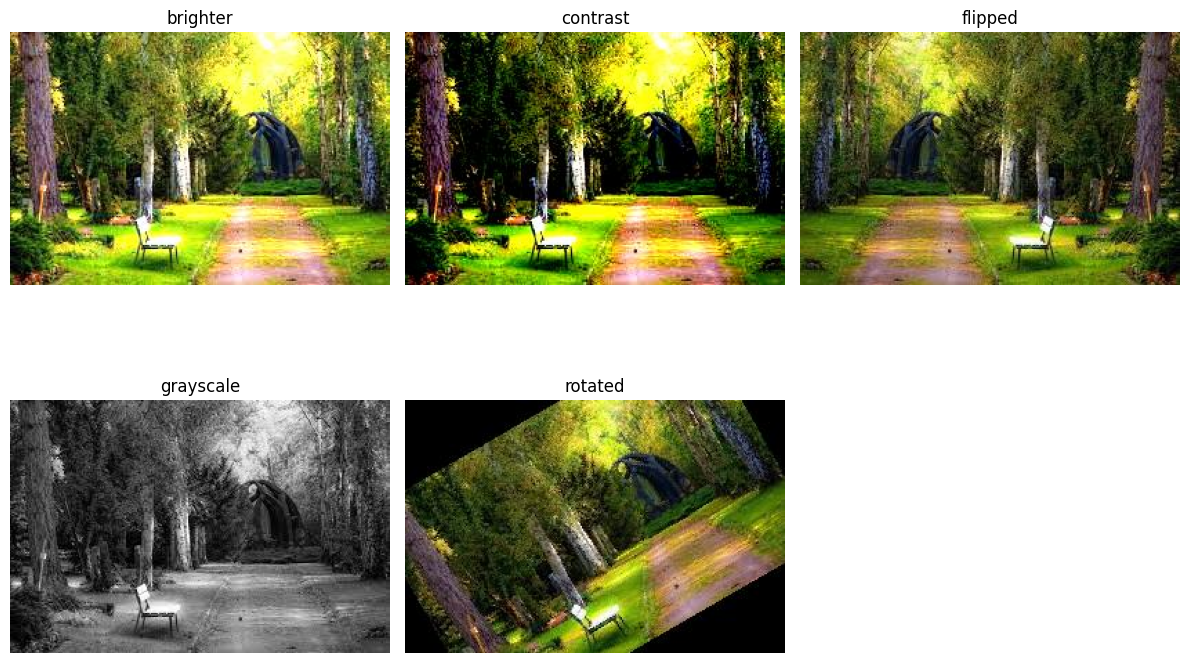

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt
import os

plt.figure(figsize=(12,8))
augmented_images = os.listdir(augmented_dir) # Define augmented_images
augmented_images.sort() # Sort the list for consistent display order
for i,img_file in enumerate(augmented_images):
  img_path = os.path.join(augmented_dir,img_file)
  img = Image.open(img_path)
  plt.subplot(2,3,i+1)
  plt.imshow(img,cmap="gray" if img.mode == "L" else None)
  plt.title(img_file.split('.')[0])
  plt.axis("off")
plt.tight_layout()
plt.show()